In [1]:
from model import DyMoTree
from utils import seed_all
seed_all(111, deterministic=True)
dmt = DyMoTree(d_path='/data02/work/wangjiayi/Data/scRNA/Simulated/',
                 task='tree1',
                 n_neighbor=50,
                 device='cuda')  

[2025-12-26 09:58:38] loading node data for Stem
[2025-12-26 09:58:40] loading node data for Child1
[2025-12-26 09:58:42] loading node data for Child2
[2025-12-26 09:58:44] calculate shortest distance for Stem with all descendant


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done  20 tasks      | elapsed:    4.3s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done  38 tasks      | elapsed:    7.1s
[Parallel(n_jobs=-1)]: Done  49 tasks      | elapsed:    8.9s
[Parallel(n_jobs=-1)]: Done  60 out of  64 | elapsed:    9.9s remaining:    0.7s
[Parallel(n_jobs=-1)]: Done  64 out of  64 | elapsed:   10.6s finished


[2025-12-26 09:58:56] loading edge data for Stem


In [2]:
seed_all(42, deterministic=True)
dmt.test(task='DMT+s1+s2',
        intra=0.5,inter=0.5,W=0.,
        pre_lr=1e-5,
        pre_iter=200,
        lr=1e-4,
        n_iter=200)
dmt.get_fate_sapce()

:: Stage1 Pre-training -- intra-graph::
:: Do pre-train Graph encoder for Stem::


100%|██████████████████████████████████████████████████| 100/100 [00:19<00:00,  5.22it/s, loss=1.28]


:: Do pre-train Graph encoder for Child1::


100%|██████████████████████████████████████████████████| 100/100 [00:10<00:00,  9.69it/s, loss=1.71]


:: Do pre-train Graph encoder for Child2::


...

:: Stage2 Pre-training -- lineage-graph::


Iter: 200/200 : 100%|██████████████████████████████████| 200/200 [02:00<00:00,  1.66it/s, loss=1.17]


:: DyMoTree Training::


Iter: 200/200 : 100%|██████████████████████████████████| 200/200 [01:51<00:00,  1.80it/s, loss=1.54]


[2025-12-26 10:03:45] get fate space of Stem


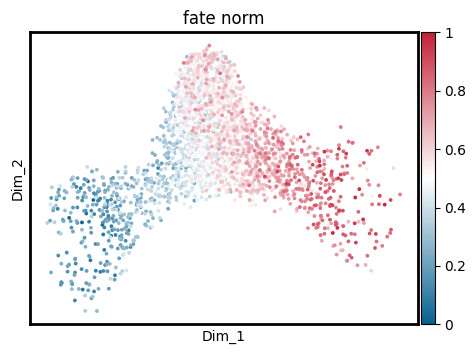

In [4]:
import scanpy as sc
import pandas as pd
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
dmt.tree_data.G.nodes['Stem']['data'].adata.obs['fate'] = dmt.tree_data.G.nodes['Stem']['data'].adata.obs['Child1_fate']/(dmt.tree_data.G.nodes['Stem']['data'].adata.obs['Child1_fate']+dmt.tree_data.G.nodes['Stem']['data'].adata.obs['Child2_fate'])
dmt.tree_data.G.nodes['Stem']['data'].adata.obs['fate1'] = pd.DataFrame(dmt.tree_data.tree['Stem']['prior_list']['prior'])['Child1'].values/(pd.DataFrame(dmt.tree_data.tree['Stem']['prior_list']['prior'])['Child1'].values+pd.DataFrame(dmt.tree_data.tree['Stem']['prior_list']['prior'])['Child2'].values)
custom_bwr = mcolors.LinearSegmentedColormap.from_list(
    "custom_bwr", 
    [(0,"#066190"), (0.5,"white"), (1,"#c42238")]
)
norm = mcolors.TwoSlopeNorm(vmin=dmt.tree_data.G.nodes['Stem']['data'].adata.obs['fate1'].values.min(), 
                            vcenter=0.5,
                            vmax=dmt.tree_data.G.nodes['Stem']['data'].adata.obs['fate1'].values.max())
dmt.tree_data.G.nodes['Stem']['data'].adata.obs['fate_norm'] = norm(dmt.tree_data.G.nodes['Stem']['data'].adata.obs['fate1'])

with rc_context({'figure.figsize': (5, 4)}):
    ax = sc.pl.scatter(
        dmt.tree_data.G.nodes['Stem']['data'].adata,
        x='Dim_1',
        y='Dim_2',
        color='fate_norm', 
        size=30,
        color_map=custom_bwr,
        frameon=True,
        show=False
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        #plt.savefig("./Fig5/CART.fate_bias.png",bbox_inches='tight')
    plt.show()

In [15]:
# find cell state
seed_all(42, deterministic=True)
# find cell state
dmt.find_state(n_state=3,
               n_pca=10,
               n_diff=10,
               n_gene=100,
               method='spearman')

[2025-12-26 10:08:58] find cell state of Stem
[2025-12-26 10:08:59] Filtering Data by fate space
[2025-12-26 10:09:01] PCA transformation
[2025-12-26 10:09:02] Run Diffusion map
[2025-12-26 10:09:05] Find archetypes


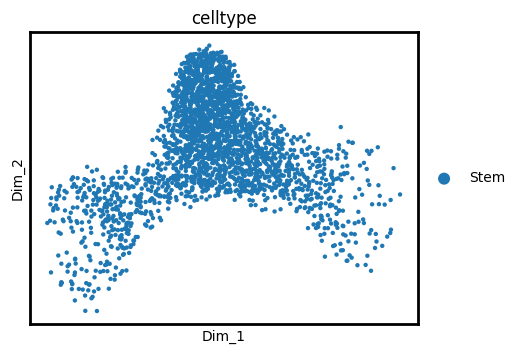

In [26]:
with rc_context({'figure.figsize': (5, 4)}):
    ax = sc.pl.scatter(
        dmt.tree_data.G.nodes['Stem']['data'].adata,
        x='Dim_1',
        y='Dim_2',
        color='celltype', 
        size=40,
        color_map=custom_bwr,
        frameon=False,
        show=False
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    plt.show()

/tmp/ipykernel_2417064/2003943022.py:21: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_to_plot.obs['Fate_State'] = adata_to_plot.obs['Fate_State'].replace(replacement_map)
/tmp/ipykernel_2417064/2003943022.py:25: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['Fate_State'] = adata.obs['Fate_State'].replace(replacement_map_adata)


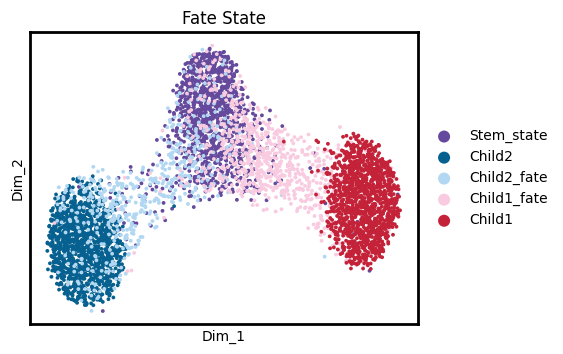

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
import scanpy as sc
import anndata
import pandas as pd

adata_merged = anndata.concat(
    [dmt.tree_data.G.nodes[cell]['data'].adata for cell in dmt.init_tree.keys()]
)
adata_to_plot = adata_merged.copy()
adata = dmt.tree_data.G.nodes['Stem']['data'].adata.copy()

# rename DyMoTree Cell State
import pandas as pd
replacement_map = {'Stem_0': 'Stem_state','Stem_1':'Child1_fate','Stem_2':'Child2_fate','Child1':'Child1','Child2':'Child2'}
replacement_map_adata = {'Stem_0': 'Stem_state','Stem_1':'Child1_fate','Stem_2':'Child2_fate'}
new_order = ['Stem_state','Child2','Child2_fate','Child1_fate','Child1']
new_order_adata = ['Child2_fate','Stem_state','Child1_fate']
adata_to_plot.obs['Fate_State'] = adata_to_plot.obs['Fate_State'].astype('category')
adata_to_plot.obs['Fate_State'] = adata_to_plot.obs['Fate_State'].replace(replacement_map)
adata_to_plot.obs['Fate_State'] = adata_to_plot.obs['Fate_State'].astype(pd.CategoricalDtype(categories=new_order, ordered=True))

adata.obs['Fate_State'] = adata.obs['Fate_State'].astype('category')
adata.obs['Fate_State'] = adata.obs['Fate_State'].replace(replacement_map_adata)
adata.obs['Fate_State'] = adata.obs['Fate_State'].astype(pd.CategoricalDtype(categories=new_order_adata, ordered=True))

adata_to_plot.obs['Fate_State'] = adata_to_plot.obs['Fate_State'].astype('category')
new_order =  ['Stem_state','Child2','Child2_fate','Child1_fate','Child1']
adata_to_plot.obs['Fate_State'] = adata_to_plot.obs['Fate_State'].astype(pd.CategoricalDtype(categories=new_order, ordered=True))
adata_to_plot.obs['celltype'] = adata_to_plot.obs['celltype'].astype('category')
new_order =  ['Child2','Stem','Child1']
adata_to_plot.obs['celltype'] = adata_to_plot.obs['celltype'].astype(pd.CategoricalDtype(categories=new_order, ordered=True))


adata.obs['Fate_State'] = adata.obs['Fate_State'].astype('category')
new_order_adata = ['Child1_fate','Child2_fate','Stem_state']
adata.obs['Fate_State'] = adata.obs['Fate_State'].astype(pd.CategoricalDtype(categories=new_order_adata, ordered=True))
adata.obs['celltype'] = adata.obs['celltype'].astype('category')
new_order_adata = ['Stem']
adata.obs['celltype'] = adata.obs['celltype'].astype(pd.CategoricalDtype(categories=new_order_adata, ordered=True))

color_map_state = {
    'Child2_fate': '#b1d7f2',
    'Stem_state': '#64499d',
    'Child1_fate': '#f8cbe0',
    'Child2':'#066190',
    'Child1':'#c42238'
}
 
color_map_adata = {
    'Child2_fate': '#b1d7f2',
    'Stem_state': '#64499d',
    'Child1_fate': '#f8cbe0'
}
state_color_list = [color_map_state[cat] for cat in adata_to_plot.obs['Fate_State'].cat.categories]
adata_to_plot.uns['Fate_State_colors'] = state_color_list
state_color_list_adata = [color_map_adata[cat] for cat in adata.obs['Fate_State'].cat.categories]
adata.uns['Fate_State_colors'] = state_color_list_adata

color_map_celltype_adata = {
    'Stem': '#C5C1D8'
}
color_map_celltype = {
    'Child1': '#c42238',
    'Stem':'#C5C1D8',
    'Child2':'#066190'
}
celltype_color_list = [color_map_celltype[cat] for cat in adata_to_plot.obs['celltype'].cat.categories]
adata_to_plot.uns['celltype_colors'] = celltype_color_list
celltype_color_list = [color_map_celltype_adata[cat] for cat in adata.obs['celltype'].cat.categories]
adata.uns['celltype_colors'] = celltype_color_list


with rc_context({'figure.figsize': (5, 4)}):
    ax = sc.pl.scatter(
        adata_to_plot,
        x='Dim_1',
        y='Dim_2',
        color='Fate_State',  
        size=30,
        frameon=False,
        show=False
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    #plt.savefig("./Fig5/CART.Fate_State.png",bbox_inches='tight')
    plt.show()